# Tech Challenge Fase 3 - Machine Learning Engineering

**Projeto:** Análise e modelagem preditiva de atrasos em voos (EUA)

**Conteúdo:**
- Exploração dos dados (EDA)
- Tratamento de valores ausentes
- Modelagem supervisionada (Classificação e Regressão)
- Modelagem não supervisionada (Clusterização e PCA)
- Conclusões e próximos passos

---


## 1. Configuração e carregamento dos dados

In [29]:
# Bloco 1

import os

_n = os.cpu_count() or 8
os.environ["OMP_NUM_THREADS"] = str(_n)
os.environ["OPENBLAS_NUM_THREADS"] = str(_n)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(_n)   # Accelerate/vecLib no macOS
os.environ["NUMEXPR_NUM_THREADS"] = str(_n)

# Opcional: scikit-learn já usa n_jobs=-1 nos modelos; isso otimiza numpy/pandas por baixo
print(f"Threads configurados para ML/NumPy: {_n} (Apple Silicon)")

Threads configurados para ML/NumPy: 14 (Apple Silicon)


In [30]:
# Bloco 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path('data')  # Pasta onde estão flights.csv, airports.csv, airlines.csv
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [31]:
# Bloco 3

# SAMPLE_SIZE = 300_000  # use 300_000 para rodar mais rápido, ou None para todos os dados
SAMPLE_SIZE = None

flights = pd.read_csv(DATA_DIR / 'flights.csv', nrows=SAMPLE_SIZE)
airports = pd.read_csv(DATA_DIR / 'airports.csv')
airlines = pd.read_csv(DATA_DIR / 'airlines.csv')

print('Flights:', flights.shape)
print('Airports:', airports.shape)
print('Airlines:', airlines.shape)

Flights: (5819079, 31)
Airports: (322, 7)
Airlines: (14, 2)


## 2. Exploração dos dados (EDA)

In [32]:
# Bloco 4

flights.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Bloco 5

flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [34]:
# Bloco 6

flights.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,930,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,930,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0


In [35]:
# Bloco 7

flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype(int)
print('Proporção de voos atrasados (>15 min):', flights['DELAYED'].mean().round(3))
print(flights['DELAYED'].value_counts())

Proporção de voos atrasados (>15 min): 0.176
DELAYED
0    4795581
1    1023498
Name: count, dtype: int64


In [36]:
# Bloco 8

missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values('missing', ascending=False)

,missing,pct
CANCELLATION_REASON,5729195,98.46
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
AIR_TIME,105071,1.81
ELAPSED_TIME,105071,1.81
ARRIVAL_DELAY,105071,1.81
WHEELS_ON,92513,1.59


### Visualizações – Insights

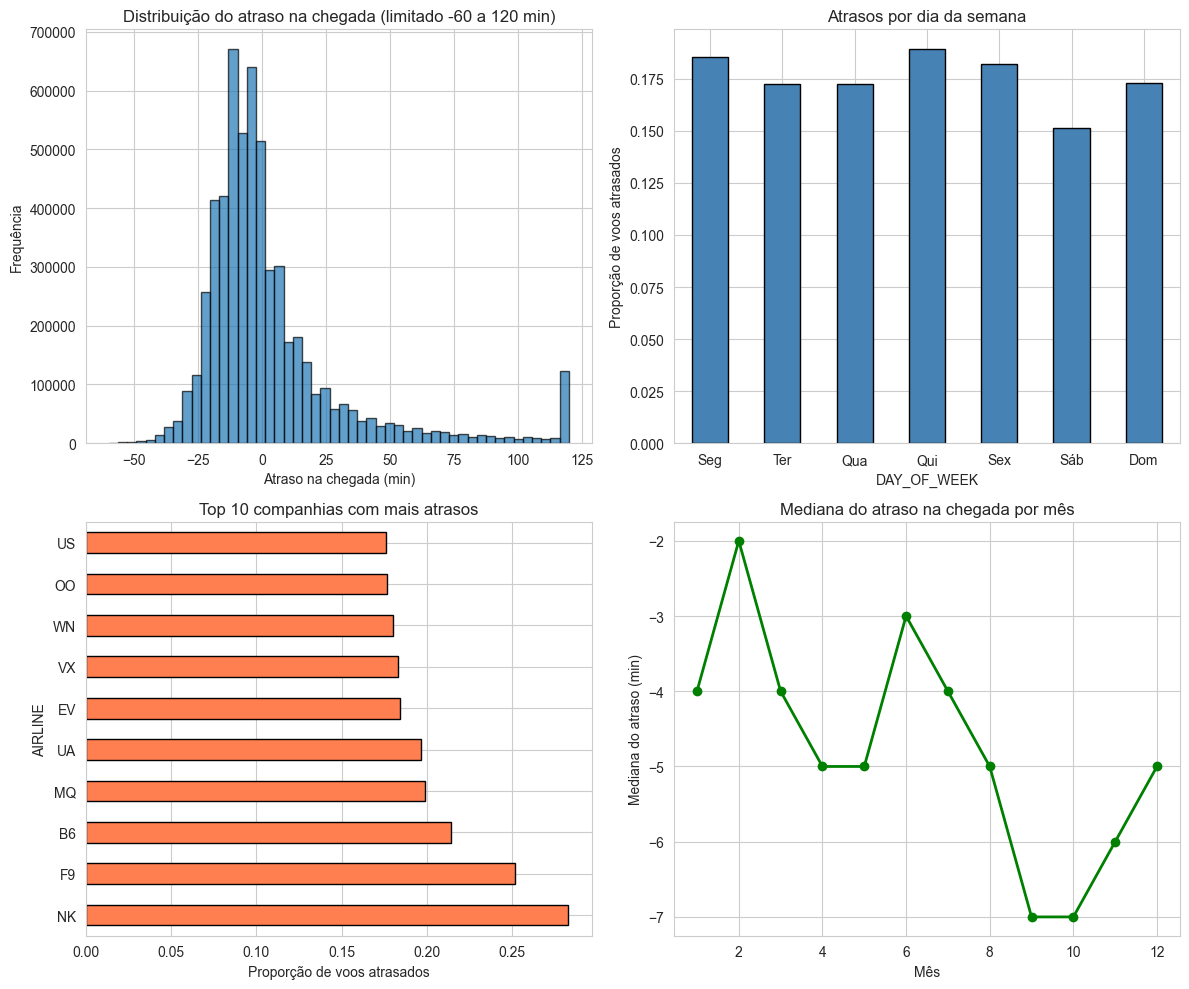

In [37]:
# Bloco 9

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribuição de atrasos na chegada
ax1 = axes[0, 0]
flights['ARRIVAL_DELAY'].clip(-60, 120).hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Atraso na chegada (min)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do atraso na chegada (limitado -60 a 120 min)')

# Atrasos por dia da semana
ax2 = axes[0, 1]
dow = flights.groupby('DAY_OF_WEEK')['DELAYED'].mean()
dow.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'], rotation=0)
ax2.set_ylabel('Proporção de voos atrasados')
ax2.set_title('Atrasos por dia da semana')

# Atrasos por companhia aérea (top 10)
ax3 = axes[1, 0]
by_airline = flights.groupby('AIRLINE')['DELAYED'].mean().sort_values(ascending=False).head(10)
by_airline.plot(kind='barh', ax=ax3, color='coral', edgecolor='black')
ax3.set_xlabel('Proporção de voos atrasados')
ax3.set_title('Top 10 companhias com mais atrasos')

# Atrasos por mês
ax4 = axes[1, 1]
by_month = flights.groupby('MONTH')['ARRIVAL_DELAY'].median()
by_month.plot(kind='line', ax=ax4, marker='o', color='green', linewidth=2)
ax4.set_ylabel('Mediana do atraso (min)')
ax4.set_xlabel('Mês')
ax4.set_title('Mediana do atraso na chegada por mês')

plt.tight_layout()
plt.show()

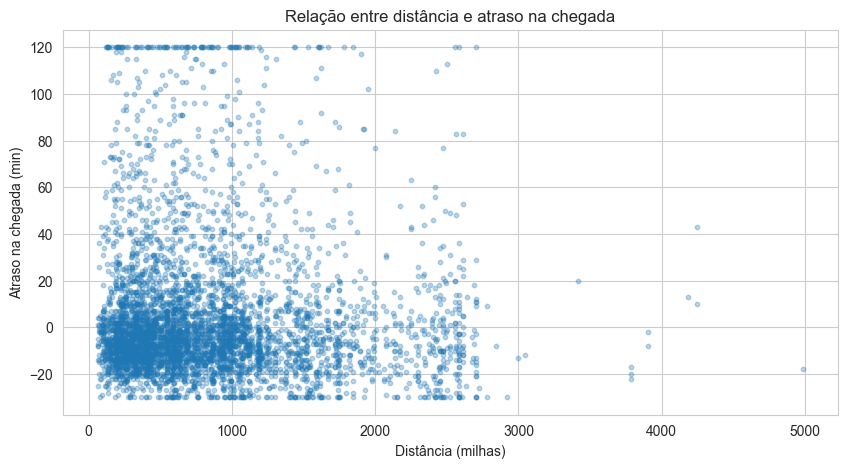

In [40]:
# Bloco 10

sample_viz = flights.sample(min(5000, len(flights)), random_state=42)
# sample_viz = flights
plt.figure(figsize=(10, 5))
plt.scatter(sample_viz['DISTANCE'], sample_viz['ARRIVAL_DELAY'].clip(-30, 120), alpha=0.3, s=10)
plt.xlabel('Distância (milhas)')
plt.ylabel('Atraso na chegada (min)')
plt.title('Relação entre distância e atraso na chegada')
plt.show()

## 3. Tratamento de valores ausentes

In [41]:
# Bloco 11

df = flights.copy()

# Remover voos cancelados e desviados para modelagem de atraso
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

# Preencher atrasos por tipo (quando ausente = 0, pois voo não sofreu aquele tipo de atraso)
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
for c in delay_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Remover linhas com ARRIVAL_DELAY ou DEPARTURE_DELAY ausentes (essenciais para o modelo)
df = df.dropna(subset=['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE', 'DISTANCE'])

print('Shape após tratamento:', df.shape)
print('Missing restantes:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape após tratamento: (5714008, 32)
Missing restantes:
CANCELLATION_REASON    5714008
dtype: int64


## 4. Preparação de features para modelagem

In [43]:
# Bloco 12

df['PERIOD_DAY'] = pd.cut(
    df['SCHEDULED_DEPARTURE'] // 100,
    bins=[0, 6, 12, 18, 24],
    labels=['madrugada', 'manha', 'tarde', 'noite']
)
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

from sklearn.preprocessing import LabelEncoder

le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_dest = LabelEncoder()
le_period = LabelEncoder()

df['AIRLINE_ENC'] = le_airline.fit_transform(df['AIRLINE'].astype(str))
df['ORIGIN_ENC'] = le_origin.fit_transform(df['ORIGIN_AIRPORT'].astype(str))
df['DEST_ENC'] = le_dest.fit_transform(df['DESTINATION_AIRPORT'].astype(str))
df['PERIOD_ENC'] = le_period.fit_transform(df['PERIOD_DAY'].astype(str))

feature_cols = ['MONTH', 'DAY_OF_WEEK', 'DEPARTURE_DELAY', 'DISTANCE', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'PERIOD_ENC']
X = df[feature_cols]
y_class = df['DELAYED']
y_reg = df['ARRIVAL_DELAY']

print('Features:', feature_cols)
print('Amostras:', len(X))

Features: ['MONTH', 'DAY_OF_WEEK', 'DEPARTURE_DELAY', 'DISTANCE', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'PERIOD_ENC']
Amostras: 5714008


In [44]:
# Bloco 13

from sklearn.model_selection import train_test_split

X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.25, random_state=42, stratify=y_class)
y_train_r = y_reg.loc[X_train.index].values
y_test_r = y_reg.loc[X_test.index].values

print('Train size:', len(X_train), 'Test size:', len(X_test))

Train size: 4285506 Test size: 1428502


## 5. Modelagem supervisionada

### 5.1 Classificação: prever se o voo atrasa ou não

In [45]:
# Bloco 14

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
}

results_clf = []
for name, model in models_clf.items():
    model.fit(X_train, y_train_c)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    results_clf.append({
        'model': name,
        'accuracy': accuracy_score(y_test_c, y_pred),
        'precision': precision_score(y_test_c, y_pred, zero_division=0),
        'recall': recall_score(y_test_c, y_pred, zero_division=0),
        'f1': f1_score(y_test_c, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test_c, y_proba) if y_proba is not None else None
    })
    print(f'\n--- {name} ---')
    print(classification_report(y_test_c, y_pred, target_names=['Não atrasado', 'Atrasado']))
    print(confusion_matrix(y_test_c, y_pred))


--- Logistic Regression ---
              precision    recall  f1-score   support

Não atrasado       0.94      0.98      0.96   1172628
    Atrasado       0.90      0.72      0.80    255874

    accuracy                           0.93   1428502
   macro avg       0.92      0.85      0.88   1428502
weighted avg       0.93      0.93      0.93   1428502

[[1151356   21272]
 [  72314  183560]]

--- Random Forest ---
              precision    recall  f1-score   support

Não atrasado       0.94      0.98      0.96   1172628
    Atrasado       0.90      0.71      0.80    255874

    accuracy                           0.94   1428502
   macro avg       0.92      0.85      0.88   1428502
weighted avg       0.93      0.94      0.93   1428502

[[1153098   19530]
 [  72962  182912]]


In [46]:
# Bloco 15
pd.DataFrame(results_clf).set_index('model').round(4)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.9345,0.8961,0.7174,0.7969,0.9280
Random Forest,0.9353,0.9035,0.7149,0.7982,0.9372


### 5.2 Regressão: prever quanto tempo dura o atraso

In [47]:
# Bloco 16

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_reg = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
}

results_reg = []
for name, model in models_reg.items():
    model.fit(X_train, y_train_r)
    y_pred = model.predict(X_test)
    results_reg.append({
        'model': name,
        'MAE': mean_absolute_error(y_test_r, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred)),
        'R2': r2_score(y_test_r, y_pred)
    })
    print(f'\n--- {name} ---')
    print(f'MAE: {mean_absolute_error(y_test_r, y_pred):.2f} min')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred)):.2f} min')
    print(f'R2: {r2_score(y_test_r, y_pred):.4f}')

pd.DataFrame(results_reg).set_index('model').round(4)


--- Ridge ---
MAE: 8.95 min
RMSE: 12.69 min
R2: 0.8948

--- Random Forest Regressor ---
MAE: 8.75 min
RMSE: 12.47 min
R2: 0.8984


,MAE,RMSE,R2
model,,,
Ridge,8.9513,12.6936,0.8948
Random Forest Regressor,8.7455,12.4722,0.8984


## 6. Modelagem não supervisionada

### 6.1 Agrupamento de aeroportos (clusterização)

In [48]:
# Bloco 17

agg_origin = df.groupby('ORIGIN_AIRPORT').agg(
    mean_dep_delay=('DEPARTURE_DELAY', 'mean'),
    mean_arr_delay=('ARRIVAL_DELAY', 'mean'),
    total_flights=('FLIGHT_NUMBER', 'count'),
    mean_distance=('DISTANCE', 'mean')
).reset_index()

# Normalizar para clusterização
from sklearn.preprocessing import StandardScaler
X_airport = agg_origin[['mean_dep_delay', 'mean_arr_delay', 'total_flights', 'mean_distance']]
scaler = StandardScaler()
X_airport_scaled = scaler.fit_transform(X_airport)

agg_origin.head(10)

,ORIGIN_AIRPORT,mean_dep_delay,mean_arr_delay,total_flights,mean_distance
0,10135,10.075221,7.601770,226,596.331858
1,10136,2.270718,-6.513812,181,158.000000
2,10140,5.603995,0.320799,1702,731.237368
3,10141,1.803030,0.606061,66,257.000000
4,10146,9.740741,11.987654,81,145.000000
5,10154,22.857143,25.535714,28,172.000000
6,10155,-4.133333,-12.725926,135,89.000000
7,10157,12.427273,9.500000,110,250.000000
8,10158,0.052402,-4.882096,229,835.965066
9,10165,17.555556,19.555556,9,1192.000000


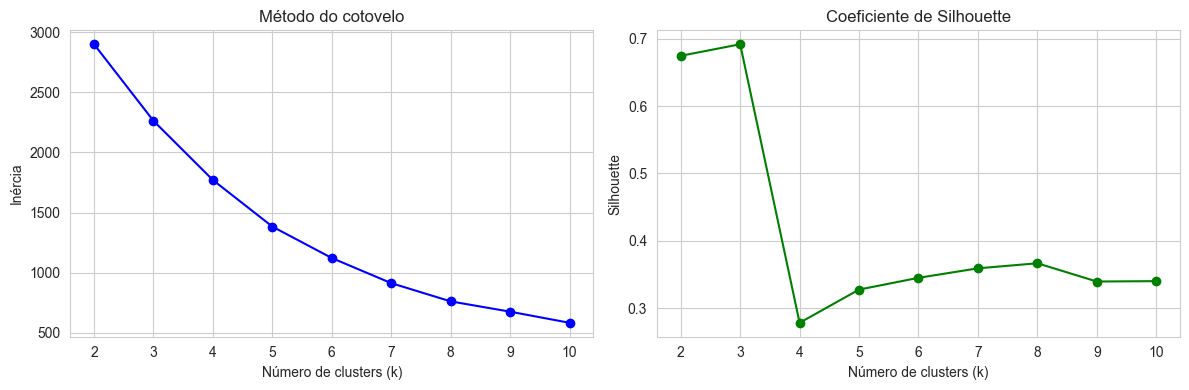

In [49]:
# Bloco 18

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_airport_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_airport_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do cotovelo')
ax2.plot(K_range, silhouettes, 'go-')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette')
ax2.set_title('Coeficiente de Silhouette')
plt.tight_layout()
plt.show()

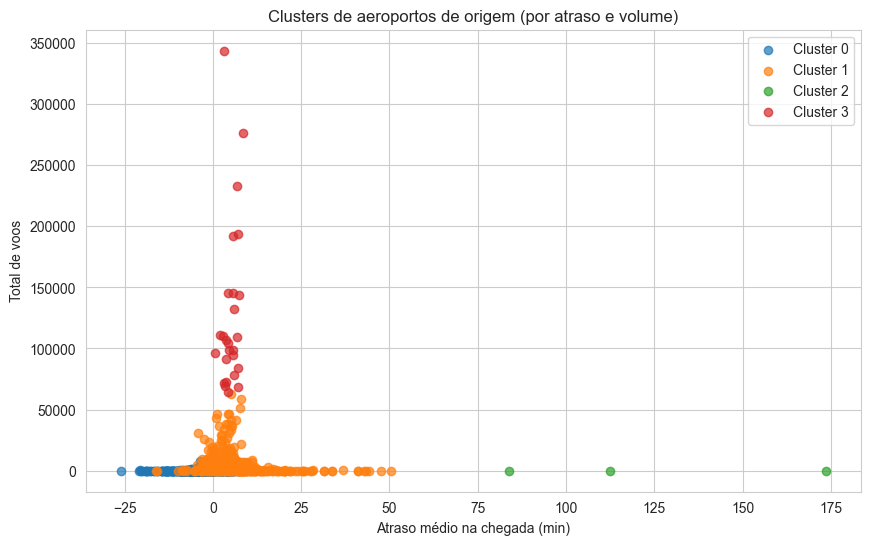


Interpretação: clusters agrupam aeroportos com perfis semelhantes de atraso e volume de voos.


In [50]:
# Bloco 19

k_best = 4  # escolha com base no cotovelo/silhouette
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
agg_origin['cluster'] = kmeans.fit_predict(X_airport_scaled)

plt.figure(figsize=(10, 6))
for c in range(k_best):
    subset = agg_origin[agg_origin['cluster'] == c]
    plt.scatter(subset['mean_arr_delay'], subset['total_flights'], label=f'Cluster {c}', alpha=0.7)
plt.xlabel('Atraso médio na chegada (min)')
plt.ylabel('Total de voos')
plt.legend()
plt.title('Clusters de aeroportos de origem (por atraso e volume)')
plt.show()

print('\nInterpretação: clusters agrupam aeroportos com perfis semelhantes de atraso e volume de voos.')

### 6.2 Redução de dimensionalidade (PCA)

In [51]:
# Bloco 20

from sklearn.decomposition import PCA

pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_airport_scaled)

print('Variância explicada por componente:', pca.explained_variance_ratio_.round(4))
print('Variância acumulada:', np.cumsum(pca.explained_variance_ratio_).round(4))

Variância explicada por componente: [0.495  0.293  0.1993 0.0127]
Variância acumulada: [0.495  0.788  0.9873 1.    ]


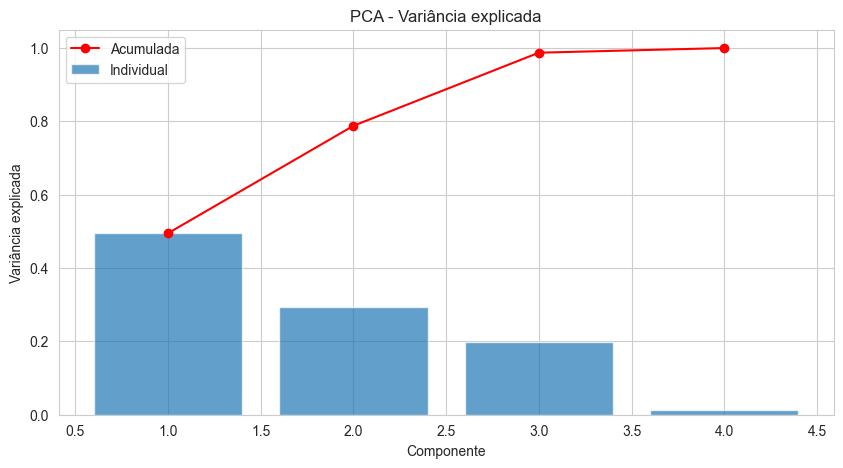

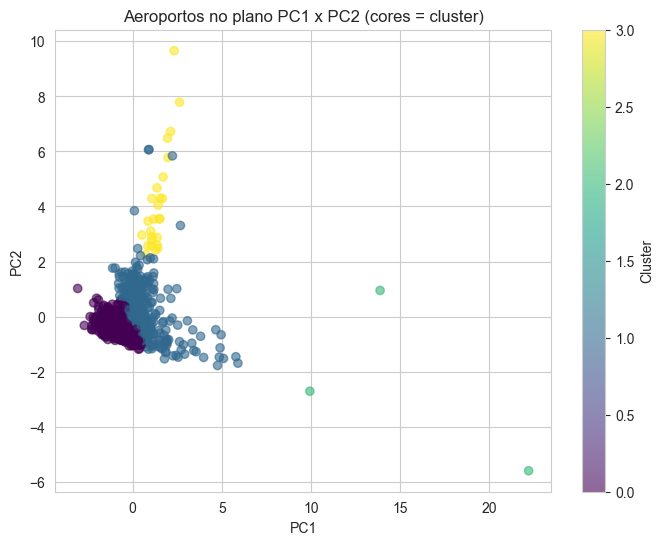

In [52]:
# Bloco 21

plt.figure(figsize=(10, 5))
plt.bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Acumulada')
plt.xlabel('Componente')
plt.ylabel('Variância explicada')
plt.legend()
plt.title('PCA - Variância explicada')
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_origin['cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Aeroportos no plano PC1 x PC2 (cores = cluster)')
plt.show()

## 7. Conclusões, limitações e próximos passos

### Principais conclusões
- **EDA:** Atrasos na chegada variam por dia da semana, companhia aérea e mês; a distribuição é assimétrica (muitos voos no horário ou adiantados, cauda longa de atrasos).
- **Classificação:** Random Forest tende a superar Regressão Logística em F1/ROC-AUC ao capturar não linearidades; DEPARTURE_DELAY e companhia/aeroporto são preditores fortes.
- **Regressão:** Modelos conseguem explicar parte da variância do atraso (R² moderado); erros absolutos (MAE/RMSE) indicam utilidade prática limitada para previsão ponto a ponto.
- **Clusterização:** Aeroportos se agrupam em perfis (alto volume + alto atraso, baixo volume + baixo atraso, etc.), útil para priorizar intervenções.
- **PCA:** Duas primeiras componentes explicam boa parte da variância; projeção no plano PC1–PC2 é coerente com os clusters.

### Limitações
- Uso de amostra (300k linhas) para tempo de execução; resultados podem variar no dataset completo.
- Variáveis como clima e eventos externos não estão no dataset; atrasos podem ser subestimados ou mal explicados.
- Label encoding para aeroporto/companhia ignora ordem; One-Hot ou embeddings poderiam melhorar.
- Métricas de regressão (MAE/RMSE) podem ser sensíveis a outliers de atraso.

### Melhorias e próximos passos
- Incluir variáveis externas (feriados, estações, clima) e features de agregação (média de atraso por rota nos últimos N dias).
- Testar outros algoritmos (XGBoost, LightGBM) e tuning de hiperparâmetros (GridSearchCV).
- Tratar desbalanceamento na classificação (pesos de classe, SMOTE ou threshold ótimo).
- Construir dashboard interativo (Streamlit/Dash) para visualização de rotas e atrasos.
- Validar modelos em período fora da amostra (hold-out temporal).